# **Detecção de GPS Spoofing em UAS (Sistemas de Aeronaves Não Tripuladas)**
---
## **1. Contexto**
Esse notebook é um estudo do uso de modelos de Machine Learning para detecção e classificação de ataques de _spoofing de GPS_ em **sistemas de aeronaves não tripuladas (UAS).** O dataset utilizado é provido pela _University of North Dakota_, e inclui dados extraídos de sinais de GPS _autênticos_ coletados usando um **receptor de GPS de 8 canais** instalado no topo de um veículo com velocidade variando entre 0 e 96 km/h emulando o vôo do UAS, além de **três posições estáticas no topo de diferentes prédios** (com diferentes altitudes) para emular a operação do UAS. Ele apresenta **13 features** extraídas em cada um dos oito canais paralelos. Em adição, três tipos de ataques de spoofing foram simulados: **simplista, intermediário e sofisticado.**

### **1.1 Descrição das features**
| Feature | O que representa |
| --- | --- |
| PRN | Identificador (_Pseudo-Random Noise_) do satélite de GPS associado ao canal. |
| Carrier Doppler | Deslocamento Doppler da portadora, em Hz. |
| Pseudorange | Pseudodistância estimada entre receptor e satélite, em metros. |
| RX Time | Tempo de recepção registrado pelo receptor, em segundos. |
| TOW at current symbol | _Time of Week:_ tempo decorrido desde o início da semana GPS, em segundos. |
| Carrier phase cycles | Diferença de fase entre a portadora recebida e a réplica gerada localmente, medida em ciclos. |
| EC | Saída do correlator antecipado (_Early Correlator_), localizado ½ chip antes do correlator prompt. |
| LC | Saída do correlator atrasado (_Late Correlator_), localizado ½ chip depois do correlator prompt. |
| PC | Medida de correlação entre o sinal recebido e a réplica local do código do satélite. (_Prompt Correlator_) |
| PIP | Componente em fase (I) da saída do correlator prompt. (_Prompt In-Phase Component_) |
| PQP | Componente em quadratura (Q) da saída do correlator prompt. (_Prompt Quadrature Component_) |
| TCD | Doppler estimado pelos tracking loops durante o processamento/correlação do sinal. (_Tracking Carrier Doppler_) |
| CN0 | _Carrier-to-Noise Ratio:_ relação entre a potência da portadora e o ruído, em dB-Hz. |
---
## **2. Importação e carregamento**

In [1]:
# Inclusão das bibliotecas auxiliares;
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set_theme(style="ticks")

In [ ]:
# Carregamento do dataset:
data = pd.read_parquet(
    "/home/luish/VSCode/IC/Datasets/GPS_Dataset_3D_8_Channels_Authentic_and_Simulated.parquet",
    engine="fastparquet"
)

# OBS - previamente, o dataset foi obtido em XLSX, mas para agilizar leituras futuras, transformei-o em parquet e o salvei assim. 
# É bem mais rápido, e já inclui a remoção da segunda linha de cabeçalho (inútil)

- O dataset possui inicialmente 158.176 registros e 112 colunas. Após a remoção da segunda linha de cabeçalho, restam 158.175 registros de dados. As 112 colunas correspondem às 14 categorias de dados presentes no arquivo (13 features + Output), cada uma disponibilizada para os 8 canais do receptor.

- O arquivo utiliza uma estrutura de cabeçalho em dois níveis. A primeira linha identifica a qual canal cada coluna pertence (ch0 a ch7), enquanto os nomes das features aparecem na primeira coluna de cada grupo de oito colunas. Como o arquivo foi carregado sem especificar um cabeçalho multinível, o pandas interpreta apenas a primeira linha como nomes das colunas, atribuindo Unnamed às demais colunas dos grupos.

- Os dados foram inicialmente carregados como object, pois a primeira linha dos dados contém os identificadores dos canais (ch0–ch7), fazendo com que o pandas não consiga interpretar diretamente as colunas como exclusivamente numéricas.

---
## **3. Análise Exploratória de Dados**
Nessa seção, antes de treinar qualquer modelo, vamos analisar e explorar o dataset e sua estrutura, fazendo ajustes quando necessário.

### **3.1 Verificações iniciais**

In [5]:
# Verificação de valores nulos;
data.isna().sum()

PRN             0
Unnamed: 1      0
Unnamed: 2      0
Unnamed: 3      0
Unnamed: 4      0
               ..
Unnamed: 107    0
Unnamed: 108    0
Unnamed: 109    0
Unnamed: 110    0
Unnamed: 111    0
Length: 112, dtype: int64

De acordo com a verificação, o dataset não possui valores ausentes, ou seja, não há necessidade de remoção ou imputação de registros devido a valores NaN.

In [6]:
data["Output"].value_counts()

Output
0    136022
2     13653
3      6000
1      2500
Name: count, dtype: int64

Essa célula retorna o Output do primeiro canal (ch0), e com isso podemos ver a proporção das classes. A classe 0 domina fortemente, com ~86%, seguida pela classe 2, com ~8,6%, classe 3, com ~3,8%, e por último a classe 1, com ~1,6%

In [7]:
outputs = data.iloc[:, -8:].apply(pd.to_numeric)

outputs.apply(pd.Series.value_counts)

,Output,Unnamed: 105,Unnamed: 106,Unnamed: 107,Unnamed: 108,Unnamed: 109,Unnamed: 110,Unnamed: 111
0,136022,136822,152293.0,142100,142474,143591.0,142663.0,139680
1,2500,4502,5882.0,9174,5900,5500.0,3000.0,5322
2,13653,12924,NaN,5975,5801,NaN,NaN,5879
3,6000,3927,NaN,926,4000,9084.0,12512.0,7294


### **3.2 Distribuição das classes**

A distribuição das classes foi analisada separadamente para cada um dos oito canais do receptor. Observa-se que a quantidade de amostras de cada classe varia entre os canais. A classe 0 é predominante em todos os canais, enquanto as classes associadas aos diferentes tipos de spoofing apresentam frequências menores e, em alguns canais, determinadas classes não estão presentes.

Essa diferença de distribuição entre canais deve ser considerada posteriormente na preparação dos dados para os modelos de Machine Learning.

In [8]:
# Adaptação para deixar o dataframe mais legível;
features = [
    "PRN",
    "Carrier_Doppler_hz",
    "Pseudorange_m",
    "RX_time",
    "TOW_at_current_symbol_s",
    "Carrier_phase_cycles",
    "EC",
    "LC",
    "PC",
    "PIP",
    "PQP",
    "TCD",
    "CN0",
    "Output"
]

channels = [f"ch{i}" for i in range(8)]

data.columns = [
    f"{feature}_{channel}"
    for feature in features
    for channel in channels
]

data.columns

Index(['PRN_ch0', 'PRN_ch1', 'PRN_ch2', 'PRN_ch3', 'PRN_ch4', 'PRN_ch5',
       'PRN_ch6', 'PRN_ch7', 'Carrier_Doppler_hz_ch0',
       'Carrier_Doppler_hz_ch1',
       ...
       'CN0_ch6', 'CN0_ch7', 'Output_ch0', 'Output_ch1', 'Output_ch2',
       'Output_ch3', 'Output_ch4', 'Output_ch5', 'Output_ch6', 'Output_ch7'],
      dtype='str', length=112)

In [9]:
ch0 = data[[f"{feature}_ch0" for feature in features]].copy()

ch0["Output_ch0"].value_counts().sort_index()
ch0["Output_ch0"].value_counts(normalize=True).sort_index() * 100

Output_ch0
0    85.994626
1     1.580528
2     8.631579
3     3.793267
Name: proportion, dtype: float64

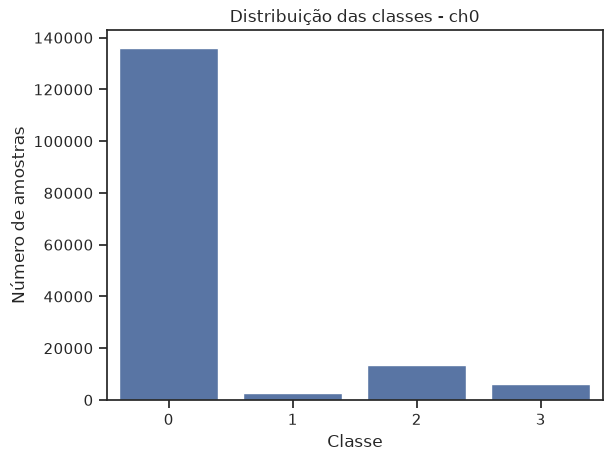

In [10]:
# Gráfico de distribuição das classes
sns.countplot(data=ch0, x="Output_ch0")

plt.title("Distribuição das classes - ch0")
plt.xlabel("Classe")
plt.ylabel("Número de amostras")
plt.show()

A variável `Output` representa a categoria do sinal GPS. A codificação utilizada pelo
dataset é:

| Classe | Descrição |
| --- | --- |
| 0 | Sinal GPS autêntico |
| 1 | Spoofing simplista |
| 2 | Spoofing intermediário |
| 3 | Spoofing sofisticado |

O dataset apresenta, portanto, um problema de classificação multiclasse com quatro
categorias. A distribuição das classes é significativamente desbalanceada, com
predominância de sinais autênticos.

In [11]:
features_ch0 = ch0.drop(columns="Output_ch0")
features_ch0.describe().T

,count,mean,std,min,25%,50%,75%,max
PRN_ch0,158175.0,4.886853e+00,7.111190e+00,0.0,0.0,0.0,8.0,27.0
Carrier_Doppler_hz_ch0,158175.0,7.780968e+02,1.584892e+03,-2246.0,0.0,0.0,981.0,5604.0
Pseudorange_m_ch0,158175.0,3.315084e+06,7.596493e+06,-5309475.0,0.0,0.0,3609787.5,24623654.0
RX_time_ch0,158175.0,2.000672e+05,1.546745e+05,0.0,0.0,174188.0,263631.0,492039.0
TOW_at_current_symbol_s_ch0,158175.0,1.192786e+05,1.625315e+05,0.0,0.0,0.0,262856.0,492039.0
Carrier_phase_cycles_ch0,158175.0,-6.468495e+04,1.448647e+05,-699518.0,-82213.0,0.0,0.0,204841.0
EC_ch0,158175.0,4.296062e+04,5.515114e+04,0.0,0.0,0.0,97522.5,225697.0
LC_ch0,158175.0,4.290388e+04,5.506514e+04,0.0,0.0,0.0,97247.5,230452.0
PC_ch0,158175.0,4.780494e+04,6.111242e+04,0.0,0.0,0.0,108985.0,246685.0
PIP_ch0,158175.0,-3.495535e+01,7.580887e+04,-238664.0,0.0,0.0,0.0,242361.0


### **3.3 Gráficos e análises**

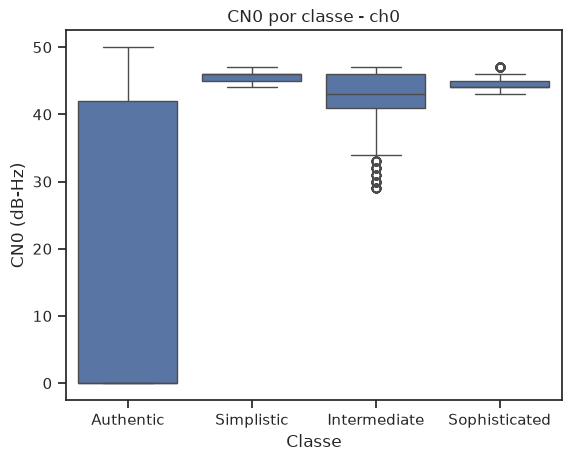

In [12]:
# Boxplot do CN0 por classe
sns.boxplot(
    data=ch0,
    x="Output_ch0",
    y="CN0_ch0"
)

plt.title("CN0 por classe - ch0")
plt.xlabel("Classe")
plt.ylabel("CN0 (dB-Hz)")

plt.xticks(
    [0, 1, 2, 3],
    ["Authentic", "Simplistic", "Intermediate", "Sophisticated"]
)

plt.show()

- A distribuição de CN0 apresenta diferenças entre as classes. Os sinais autênticos apresentam uma distribuição mais ampla, enquanto as classes de spoofing apresentam concentrações mais específicas de valores de CN0. A classe intermediária apresenta uma dispersão maior e diversos valores considerados outliers em direção aos menores valores. As classes de spoofing simplista e sofisticada apresentam distribuições semelhantes, embora a sofisticada esteja deslocada para valores ligeiramente menores.

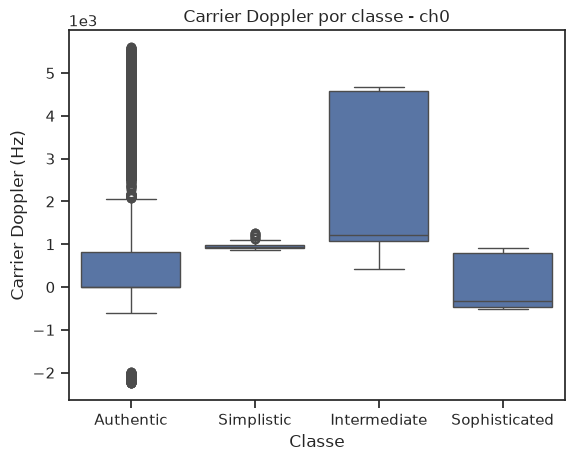

In [13]:
sns.boxplot(
    data=ch0,
    x="Output_ch0",
    y="Carrier_Doppler_hz_ch0"
)

plt.title("Carrier Doppler por classe - ch0")
plt.xlabel("Classe")
plt.ylabel("Carrier Doppler (Hz)")

plt.xticks(
    [0, 1, 2, 3],
    ["Authentic", "Simplistic", "Intermediate", "Sophisticated"]
)

plt.ticklabel_format(axis="y", style="sci", scilimits=(3, 3))

plt.show()

- O spoofing simplista exibe variabilidade quase nula em torno de 1000Hz. O spoofing intermediário atinge os maiores valores interquartis, enquanto o sofisticado opera principalmente em valores negativos, e o sinal autêntico apresenta média próxima de zero, mas quantidade absurda de outliers negativos e positivos.

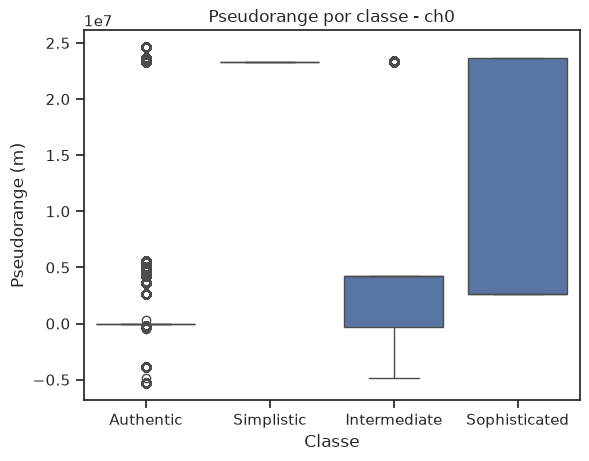

In [14]:
# Boxplot do pseudorange por classe
sns.boxplot(
    data=ch0,
    x="Output_ch0",
    y="Pseudorange_m_ch0"
)

plt.title("Pseudorange por classe - ch0")
plt.xlabel("Classe")
plt.ylabel("Pseudorange (m)")

plt.xticks(
    [0, 1, 2, 3],
    ["Authentic", "Simplistic", "Intermediate", "Sophisticated"]
)

plt.show()

- O sinal autêntico e o spoofing simplista mantém variabilidade quase nula, porém com vários outliers no autêntico. O spoofing intermediário e o sofisticado sofrem alterações drásticas na escala, sendo fortemente discriminatórios.

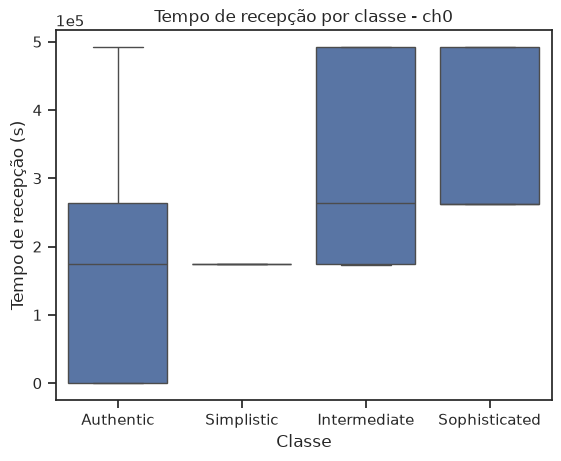

In [15]:
sns.boxplot(
    data=ch0,
    x="Output_ch0",
    y="RX_time_ch0"
)

plt.title("Tempo de recepção por classe - ch0")
plt.xlabel("Classe")
plt.ylabel("Tempo de recepção (s)")

plt.xticks(
    [0, 1, 2, 3],
    ["Authentic", "Simplistic", "Intermediate", "Sophisticated"]
)

plt.ticklabel_format(axis="y", style="sci", scilimits=(5, 5))

plt.show()

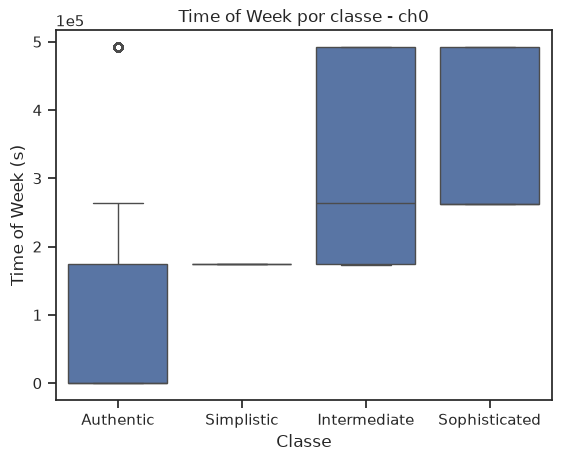

In [16]:
sns.boxplot(
    data=ch0,
    x="Output_ch0",
    y="TOW_at_current_symbol_s_ch0"
)

plt.title("Time of Week por classe - ch0")
plt.xlabel("Classe")
plt.ylabel("Time of Week (s)")

plt.xticks(
    [0, 1, 2, 3],
    ["Authentic", "Simplistic", "Intermediate", "Sophisticated"]
)

plt.ticklabel_format(axis="y", style="sci", scilimits=(5, 5))

plt.show()

- O TOW apresenta boxplot praticamente idêntico ao RX Time. O spoofing simplista é extremamente concentrado em um único ponto, enquanto o intermediário e sofisticado abrangem faixas de tempo superiores, revelando deslocamento temporal provocado por ataques avançados.

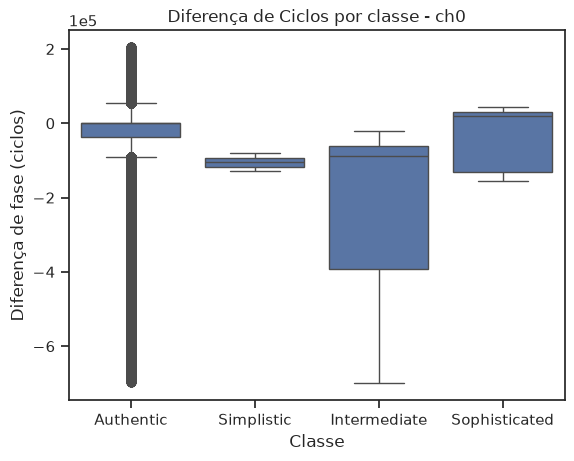

In [17]:
sns.boxplot(
    data=ch0,
    x="Output_ch0",
    y="Carrier_phase_cycles_ch0"
)

plt.title("Diferença de Ciclos por classe - ch0")
plt.xlabel("Classe")
plt.ylabel("Diferença de fase (ciclos)")

plt.xticks(
    [0, 1, 2, 3],
    ["Authentic", "Simplistic", "Intermediate", "Sophisticated"]
)

plt.ticklabel_format(axis="y", style="sci", scilimits=(5, 5))

plt.show()

- Nesses dados, há uma quantidade massiva de outliers no sinal autêntico, que formam uma linha contígua espessa cinza. Apesar disso, ainda há uma grande concentração em torno do 0. O spoofing intermediário apresenta a maior dispersão negativa.

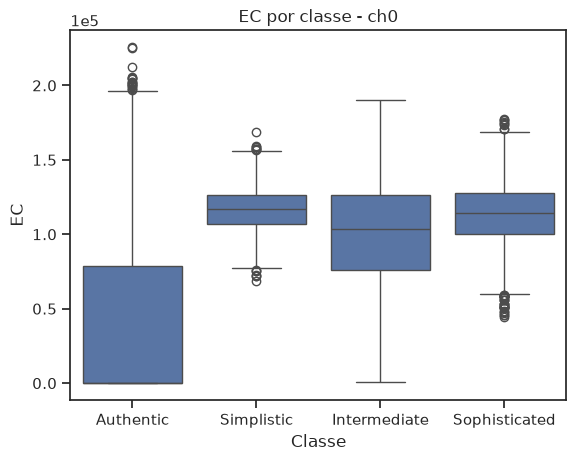

In [18]:
sns.boxplot(
    data=ch0,
    x="Output_ch0",
    y="EC_ch0"
)

plt.title("EC por classe - ch0")
plt.xlabel("Classe")
plt.ylabel("EC")

plt.xticks(
    [0, 1, 2, 3],
    ["Authentic", "Simplistic", "Intermediate", "Sophisticated"]
)

plt.ticklabel_format(axis="y", style="sci", scilimits=(5, 5))

plt.show()

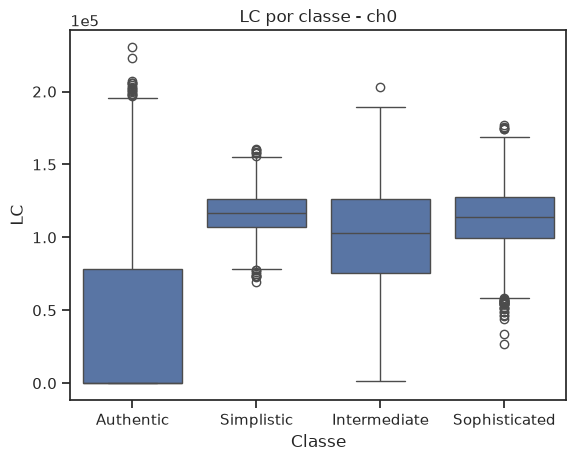

In [19]:
sns.boxplot(
    data=ch0,
    x="Output_ch0",
    y="LC_ch0"
)

plt.title("LC por classe - ch0")
plt.xlabel("Classe")
plt.ylabel("LC")

plt.xticks(
    [0, 1, 2, 3],
    ["Authentic", "Simplistic", "Intermediate", "Sophisticated"]
)

plt.ticklabel_format(axis="y", style="sci", scilimits=(5, 5))

plt.show()

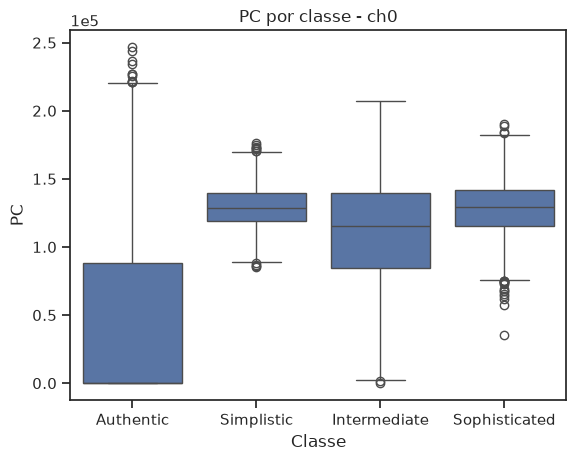

In [20]:
sns.boxplot(
    data=ch0,
    x="Output_ch0",
    y="PC_ch0"
)

plt.title("PC por classe - ch0")
plt.xlabel("Classe")
plt.ylabel("PC")

plt.xticks(
    [0, 1, 2, 3],
    ["Authentic", "Simplistic", "Intermediate", "Sophisticated"]
)

plt.ticklabel_format(axis="y", style="sci", scilimits=(5, 5))

plt.show()

- As três métricas de correlação tem padrão bastante homogêneo; O sinal autêntico possui base alargada a partir do 0. As classes de spoofing mostram elevação maior no patamar mediano, entre 100.000 e 130.000, indicando que qualquer um dos ataques eleva a energia dos correlatores no canal 0.

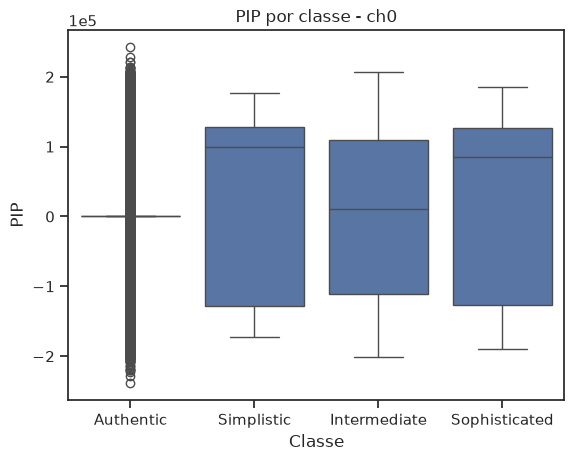

In [21]:
sns.boxplot(
    data=ch0,
    x="Output_ch0",
    y="PIP_ch0"
)

plt.title("PIP por classe - ch0")
plt.xlabel("Classe")
plt.ylabel("PIP")

plt.xticks(
    [0, 1, 2, 3],
    ["Authentic", "Simplistic", "Intermediate", "Sophisticated"]
)

plt.ticklabel_format(axis="y", style="sci", scilimits=(5, 5))

plt.show()

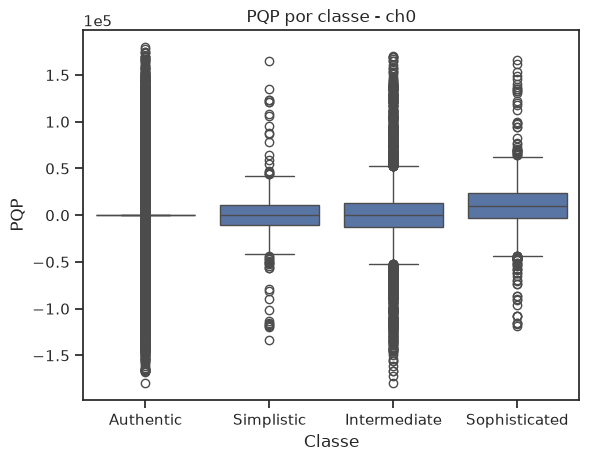

In [22]:
sns.boxplot(
    data=ch0,
    x="Output_ch0",
    y="PQP_ch0"
)

plt.title("PQP por classe - ch0")
plt.xlabel("Classe")
plt.ylabel("PQP")

plt.ticklabel_format(axis="y", style="sci", scilimits=(5, 5))

plt.xticks(
    [0, 1, 2, 3],
    ["Authentic", "Simplistic", "Intermediate", "Sophisticated"]
)

plt.show()

- PIP: O sinal autêntico apresenta concentração no zero, mas acompanha uma coluna vertical muito densa de outliers negativos e positivos. As classes de spoofing cobrem uma variabilidade maior.
- PQP: Distribuição centrada em zero para todas as classes, mas as classes do sinal autêntico e spoofing intermediário concentram muitos outliers cobrindo toda a faixa.

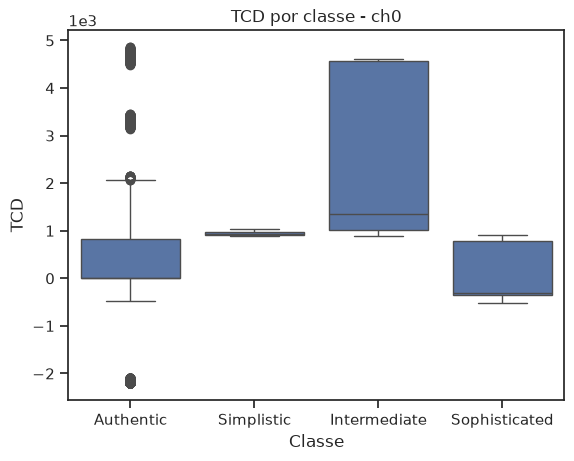

In [23]:
sns.boxplot(
    data=ch0,
    x="Output_ch0",
    y="TCD_ch0"
)

plt.title("TCD por classe - ch0")
plt.xlabel("Classe")
plt.ylabel("TCD")

plt.xticks(
    [0, 1, 2, 3],
    ["Authentic", "Simplistic", "Intermediate", "Sophisticated"]
)

plt.ticklabel_format(axis="y", style="sci", scilimits=(3, 3))

plt.show()

- Sinal autêntico: mediana próxima do 0, com quantidade densa de outliers na cauda superior e alguns outliers negativos.
- Spoofing simplista: dispersão extremamente baixa; o ataque simplista gera rigidez no sinal.
- Intermediário: variabilidade imensa; reflete o comportamento instável do Doppler manipulado.
- Sofisticado: valores predominantemente baixos ou negativos;

### **3.4 Matriz de Correlação e Análise Temporal**
- Matriz de Correlação:

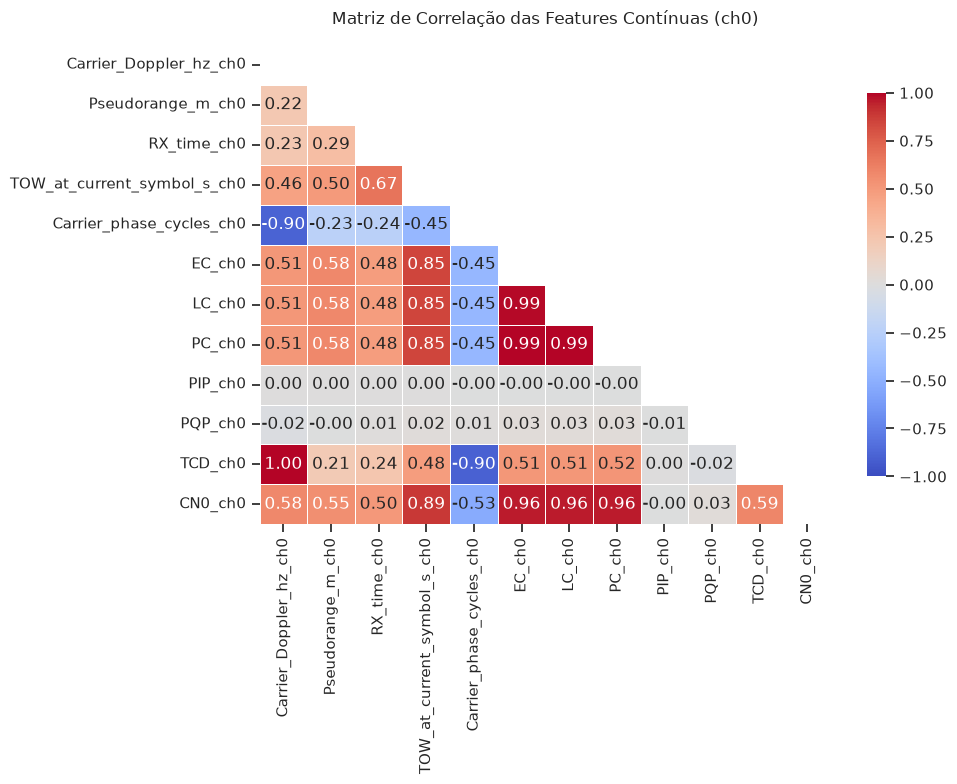

In [24]:
# Seleciona apenas as features numéricas contínuas do ch0
# Exclui PRN (categórica) e Output_ch0 (classe)
colunas_para_excluir = ['PRN_ch0', 'Output_ch0']
features_continuas = [c for c in ch0.columns if c not in colunas_para_excluir]

# Calcula a matriz de correlação
corr_matrix = ch0[features_continuas].corr()

# Cria a máscara para ocultar o triângulo superior e a diagonal principal
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plota a matriz otimizada
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Matriz de Correlação das Features Contínuas (ch0)", pad=15)
plt.tight_layout()
plt.show()

- TCD e Carrier Doppler possuem correlação linear perfeita, então a inclusão de ambas é essencialmente redundante para análise. O melhor seria excluir TCD.
- Os correlatores EC, LC e PC possuem correlação de 0.99, tendo variabilidade praticamente idêntica, então poderíamos manter somente um, ou aplicar uma redução de dimensionalidade.
- CN0 possui correlação altíssima com os correlatores e com TOW.

- Em contraste, Carrier Phase Cycles possui uma forte correlação com Doppler, refletindo uma relação inversa entre eles.
- PIP e PQP possuem correlação aproximada de 0 com todo o resto das features, não possuindo correlação linear com nenhuma outra variável do sinal. Os dados são independentes do resto do sinal, o que pode ser muito valioso pro aprendizado de máquina.

In [25]:
# Validação de correlação do Doppler e TCD em TODOS os 8 canais (ch0 a ch7)
for ch in range(8):
    tcd_col = f"TCD_ch{ch}"
    doppler_col = f"Carrier_Doppler_hz_ch{ch}"

    if tcd_col in data.columns and doppler_col in data.columns:
        corr = data[tcd_col].corr(data[doppler_col])
        print(f"Correlação TCD x Doppler no ch{ch}: {corr:.4f}")

Correlação TCD x Doppler no ch0: 0.9954
Correlação TCD x Doppler no ch1: 0.9912
Correlação TCD x Doppler no ch2: 0.9941
Correlação TCD x Doppler no ch3: 0.9983
Correlação TCD x Doppler no ch4: 0.9980
Correlação TCD x Doppler no ch5: 0.9965
Correlação TCD x Doppler no ch6: 0.9991
Correlação TCD x Doppler no ch7: 0.9951


- Pelo que podemos ver, em todos os canais é válida a correlação quase perfeita de doppler e TCD. No entanto, ao invés de descartar, vou optar por fazer uma "feature de resíduo", consistindo no módulo da diferença entre o doppler e o TCD.

In [26]:
# Listas para guardar as colunas que queremos deletar
cols_para_remover = []

for i in range(8):
    doppler_col = f'Carrier_Doppler_hz_ch{i}'
    tcd_col = f'TCD_ch{i}'
    
    # 1. Cria a feature de resíduo
    data[f'ch{i}_doppler_tcd_diff'] = np.abs(data[doppler_col] - data[tcd_col])
    
    # 2. Adiciona o nome do TCD na lista de remoção
    cols_para_remover.append(tcd_col)

# 3. Remove todas as colunas TCD do DataFrame de uma só vez
data.drop(columns=cols_para_remover, inplace=True)

In [27]:
# Média, máximo e contagem por classe da nossa feature nova.
data.groupby('Output_ch0')['ch0_doppler_tcd_diff'].agg(['mean', 'max', 'count'])

,mean,max,count
Output_ch0,,,
0,28.430232,3218,136022
1,18.175200,383,2500
2,113.412657,4190,13653
3,50.223000,190,6000


Pela pequena tabela, podemos ver a diferença entre os ataques: 
- O simplista apresenta média baixa e pico contido; Ataques simplistas tendem a sobrepor o sinal bruto ou causar perda rápida do rastreio, sem manter uma fase divergente por muito tempo.
- O intermediário apresenta uma perturbação enorme no receptor, com uma média muito elevada e máximo enorme. O ataque força a fase e a frequência sem sincronia, que destrói a coerência física.
- O sofisticado representa um comportamento relativamente "furtivo", com máximo diminuto e média significativamente menor que a do ataque intermediário (apesar de quase o dobro do sinal autêntico); O atacante tenta não gerar picos chamativos, mas altera a linha de base contínua.




- Análise Temporal:


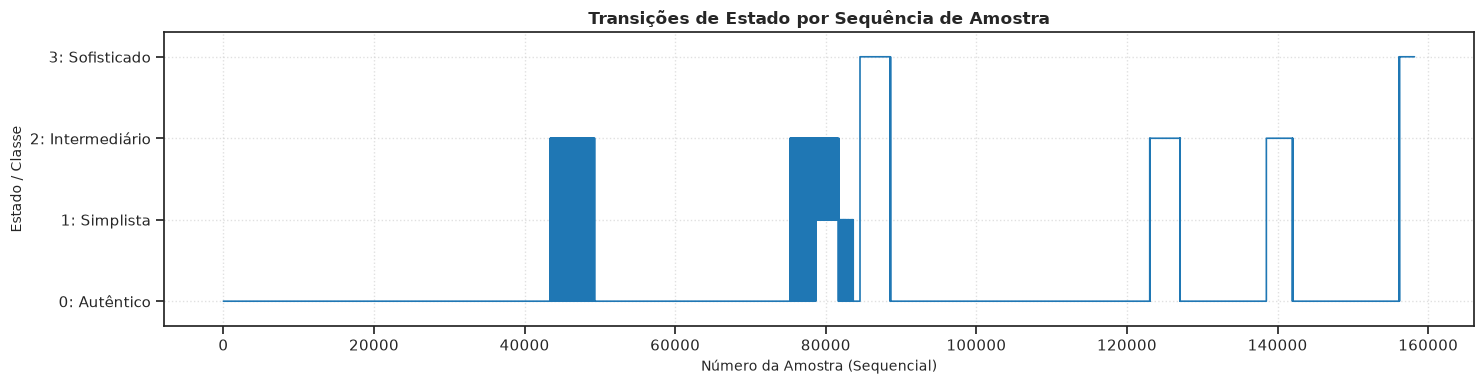

In [28]:
# Ordena temporalmente e reseta os índices
data_ordenado = data.sort_values(by='RX_time_ch0').reset_index(drop=True)

plt.figure(figsize=(15, 4))

# Plota usando o número/índice sequencial da amostra no eixo X
plt.step(
    data_ordenado.index, 
    data_ordenado['Output_ch0'], 
    where='post', 
    color='#1f77b4', 
    linewidth=1.2
)

plt.yticks([0, 1, 2, 3], ['0: Autêntico', '1: Simplista', '2: Intermediário', '3: Sofisticado'])
plt.title('Transições de Estado por Sequência de Amostra', fontsize=12, fontweight='bold')
plt.xlabel('Número da Amostra (Sequencial)', fontsize=10)
plt.ylabel('Estado / Classe', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.ylim(-0.3, 3.3)
plt.tight_layout()
plt.show()

- **Estrutura dos Ataques (Janelas Sequenciais):** O spoofing ocorre em **janelas de tempo bem delimitadas e contínuas**, sem distribuição aleatória ponto a ponto.  
**Estabilidade e Oscilação de Estado:**  
    - _Regiões Preenchidas_ (ex: Amostras ~43k-50k e ~75k-80k):  
    Ataques de perfil intermediário (Classe 2) que apresentam comutação de alta frequência e oscilação rápida entre o sinal alterado e a perda de travamento (Classe 0).

    - _Regiões Estáveis/Ocas_ (ex: Amostras ~85k e ~155k):  
    Invasões contínuas e sustentadas de perfil sofisticado (Classe 3), mantendo o estado de spoofing ativo sem interrupções bruscas.

- **Diretriz Obrigatória de Validação (ML):** Devido à alta autocorrelação temporal intra-bloco, a divisão dos dados não pode utilizar amostragem aleatória (shuffle=True). A validação cruzada deve ser feita por blocos temporais isolados, como Time-Based Split ou GroupKFold, para evitar vazamento de dados.

### **3.5 Fechamento da EDA**
- **Desbalanceamento crítico:** vemos que há um desbalanceamento gigantesco na proporção dos dados, em que os sinais autênticos aparecem muito mais. Assim, a acurácia torna-se uma métrica inadequada para avaliar de fato o desempenho final, sendo indispensável priorizar o F1-Score, o Recall das classes de ataque e a Curva Precision-Recall.  
- **Formato da matriz de entrada:** para a etapa de modelagem, os dados dos 8 canais de recepção serão concatenados por amostra temporal, consolidando um vetor de 104 variáveis de entrada (13 métricas x 8 canais).
- **Disparidade das Escalas:** há uma grande diferença de grandeza entre as métricas. Como eu só vou utilizar modelos baseados em árvores, que são insensíveis à escala dos dados, não é necessária, mas em outros casos, a padronização via StandardScaler é obrigatório caso fossem testados modelos lineares, SVMs ou Redes Neurais.
---  
  



## **4. Modelagem e Aprendizado de Máquina**
Feita a análise exploratória e pequenos pré-processamentos, vamos começar de fato o treino e teste de modelos de ML no dataset.
  
### **4.1 Limpeza inicial do dataset para o treino (Pré-processamento):**

In [29]:
# Padrões de nomes de colunas que NÃO devem ir para o treino (features temporais, a classe em si, o PRN que não é de fato relevante, e o TCD que é redundante)
padroes_remover = ['Output', 'RX_time', 'TOW', 'PRN', 'TCD']

# Identifica automaticamente todas as colunas que contêm esses padrões
cols_remover = [col for col in data.columns if any(padrão in col for padrão in padroes_remover)]

# Matriz X limpa e vetor de saída y
X = data_ordenado.drop(columns=cols_remover)
y = data_ordenado['Output_ch0']

print(f"Colunas removidas ({len(cols_remover)}):", cols_remover)
print(f"Features finais para o modelo ({X.shape[1]}):", list(X.columns))

Colunas removidas (32): ['PRN_ch0', 'PRN_ch1', 'PRN_ch2', 'PRN_ch3', 'PRN_ch4', 'PRN_ch5', 'PRN_ch6', 'PRN_ch7', 'RX_time_ch0', 'RX_time_ch1', 'RX_time_ch2', 'RX_time_ch3', 'RX_time_ch4', 'RX_time_ch5', 'RX_time_ch6', 'RX_time_ch7', 'TOW_at_current_symbol_s_ch0', 'TOW_at_current_symbol_s_ch1', 'TOW_at_current_symbol_s_ch2', 'TOW_at_current_symbol_s_ch3', 'TOW_at_current_symbol_s_ch4', 'TOW_at_current_symbol_s_ch5', 'TOW_at_current_symbol_s_ch6', 'TOW_at_current_symbol_s_ch7', 'Output_ch0', 'Output_ch1', 'Output_ch2', 'Output_ch3', 'Output_ch4', 'Output_ch5', 'Output_ch6', 'Output_ch7']
Features finais para o modelo (80): ['Carrier_Doppler_hz_ch0', 'Carrier_Doppler_hz_ch1', 'Carrier_Doppler_hz_ch2', 'Carrier_Doppler_hz_ch3', 'Carrier_Doppler_hz_ch4', 'Carrier_Doppler_hz_ch5', 'Carrier_Doppler_hz_ch6', 'Carrier_Doppler_hz_ch7', 'Pseudorange_m_ch0', 'Pseudorange_m_ch1', 'Pseudorange_m_ch2', 'Pseudorange_m_ch3', 'Pseudorange_m_ch4', 'Pseudorange_m_ch5', 'Pseudorange_m_ch6', 'Pseudorange_m_

### **4.2 Treinamento e teste dos modelos**

Amostras de Treino: 79175 | Classes no Treino: [68370  1199  6606  3000]
Amostras de Teste:  79000 | Classes no Teste:  [67652  1301  7047  3000]

================ RELATÓRIO DE DESEMPENHO (JANELAMENTO SEQUENCIAL) ================
              precision    recall  f1-score   support

           0       0.99      0.96      0.98     67652
           1       0.58      0.45      0.51      1301
           2       0.71      0.93      0.81      7047
           3       0.93      0.93      0.93      3000

    accuracy                           0.95     79000
   macro avg       0.80      0.82      0.81     79000
weighted avg       0.96      0.95      0.95     79000



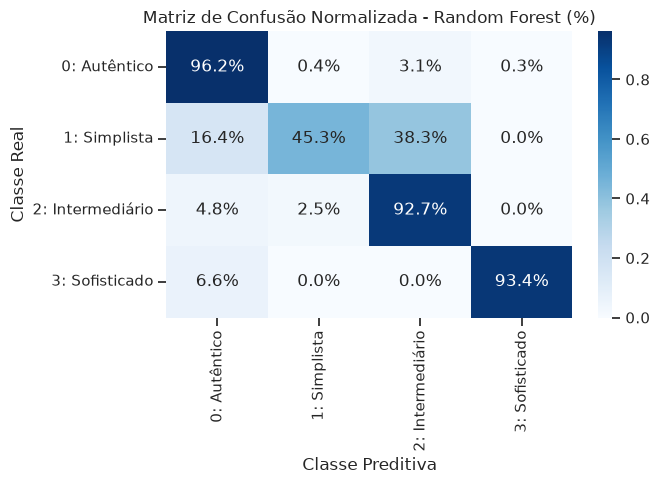

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Ordenação Temporal Estrita
data_ordenado = data.sort_values(by='RX_time_ch0').reset_index(drop=True)

# Re-identificação de Blocos
delta_t = data_ordenado['RX_time_ch0'].diff()
data_ordenado['bloco_experimento'] = (delta_t > 1000).cumsum().fillna(0).astype(int)

# Limpeza de Metadados e Contadores Brutos
padroes_remover = ['Output', 'RX_time', 'TOW', 'PRN', 'TCD']
cols_remover = [col for col in data_ordenado.columns if any(padrão in col for padrão in padroes_remover)]

# Divisão por Janelas Temporais Contínuas (Sub-blocos de 500 amostras)
# Janelas pares -> Treino | Janelas ímpares -> Teste (Garante temporalidade e cobertura de classes)
tamanho_janela = 500
data_ordenado['janela_id'] = (data_ordenado.index // tamanho_janela)

janelas = data_ordenado['janela_id'].unique()
janelas_treino = janelas[janelas % 2 == 0]
janelas_teste = janelas[janelas % 2 != 0]

X_completo = data_ordenado.drop(columns=cols_remover + ['bloco_experimento', 'janela_id'])
y_completo = data_ordenado['Output_ch0']

X_train = X_completo[data_ordenado['janela_id'].isin(janelas_treino)]
y_train = y_completo[data_ordenado['janela_id'].isin(janelas_treino)]

X_test = X_completo[data_ordenado['janela_id'].isin(janelas_teste)]
y_test = y_completo[data_ordenado['janela_id'].isin(janelas_teste)]

print(f"Amostras de Treino: {len(X_train)} | Classes no Treino: {np.bincount(y_train)}")
print(f"Amostras de Teste:  {len(X_test)} | Classes no Teste:  {np.bincount(y_test)}\n")

# Treinamento com Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    class_weight='balanced',
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Avaliação
y_pred = rf_model.predict(X_test)

print("================ RELATÓRIO DE DESEMPENHO (JANELAMENTO SEQUENCIAL) ================")
print(classification_report(y_test, y_pred, zero_division=0))

# Matriz de Confusão Normalizada em %
cm_rf_percent = confusion_matrix(y_test, y_pred, normalize='true')

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_rf_percent, 
    annot=True, 
    fmt='.1%',
    cmap='Blues',
    xticklabels=['0: Autêntico', '1: Simplista', '2: Intermediário', '3: Sofisticado'],
    yticklabels=['0: Autêntico', '1: Simplista', '2: Intermediário', '3: Sofisticado']
)
plt.title('Matriz de Confusão Normalizada - Random Forest (%)')
plt.ylabel('Classe Real')
plt.xlabel('Classe Preditiva')
plt.tight_layout()
plt.show()

- Analisando os resultados e a matriz de confusão, vemos que o Random Forest foi bem competente na classificação do sinal autêntico, relativamente bem nos ataques intermediários e sofisticados, mas bem insatisfatório na identificação do ataque simplista. A seguir, vamos testar o xgboost.


================ RELATÓRIO DE DESEMPENHO (XGBOOST OTIMIZADO) ================
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     67652
           1       0.74      0.48      0.58      1301
           2       0.79      0.89      0.84      7047
           3       0.95      0.85      0.90      3000

    accuracy                           0.96     79000
   macro avg       0.87      0.80      0.82     79000
weighted avg       0.96      0.96      0.96     79000



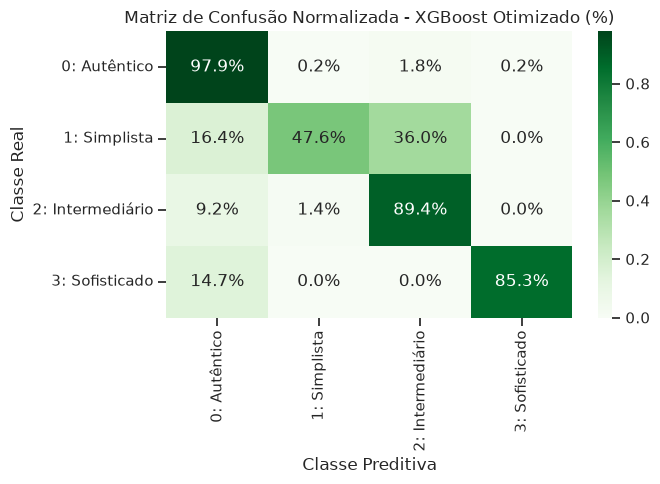

In [31]:
import xgboost as xgb

# Feature Engineering: Variação Temporal Instantânea (t - (t-1))
X_diff = X_completo.diff().fillna(0)
X_diff.columns = [f"{col}_delta" for col in X_diff.columns]
X_enriquecido = pd.concat([X_completo, X_diff], axis=1)

# Separação nas mesmas Janelas Contínuas usadas no Random Forest
X_train_xgb = X_enriquecido[data_ordenado['janela_id'].isin(janelas_treino)]
X_test_xgb = X_enriquecido[data_ordenado['janela_id'].isin(janelas_teste)]

# Inicialização e Treino do XGBoost Otimizado
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist',
    n_jobs=-1
)

xgb_model.fit(X_train_xgb, y_train)

# Predição
y_pred_xgb = xgb_model.predict(X_test_xgb)

# Relatório e Matriz de Confusão em Porcentagem (%)
print("\n================ RELATÓRIO DE DESEMPENHO (XGBOOST OTIMIZADO) ================")
print(classification_report(y_test, y_pred_xgb, zero_division=0))

cm_xgb_percent = confusion_matrix(y_test, y_pred_xgb, normalize='true')

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_xgb_percent, 
    annot=True, 
    fmt='.1%', 
    cmap='Greens', # Cor diferente para destacar a evolução em relação ao RF
    xticklabels=['0: Autêntico', '1: Simplista', '2: Intermediário', '3: Sofisticado'],
    yticklabels=['0: Autêntico', '1: Simplista', '2: Intermediário', '3: Sofisticado']
)
plt.title('Matriz de Confusão Normalizada - XGBoost Otimizado (%)')
plt.ylabel('Classe Real')
plt.xlabel('Classe Preditiva')
plt.tight_layout()
plt.show()

- Novamente, o XGBoost acabou tendo dificuldade de identificar a classe 1, sendo apenas marginalmente melhor, mas perdendo muita acurácia nas classes 2 e 3. O ideal para o dataset provavelmente será um random forest mais refinado.

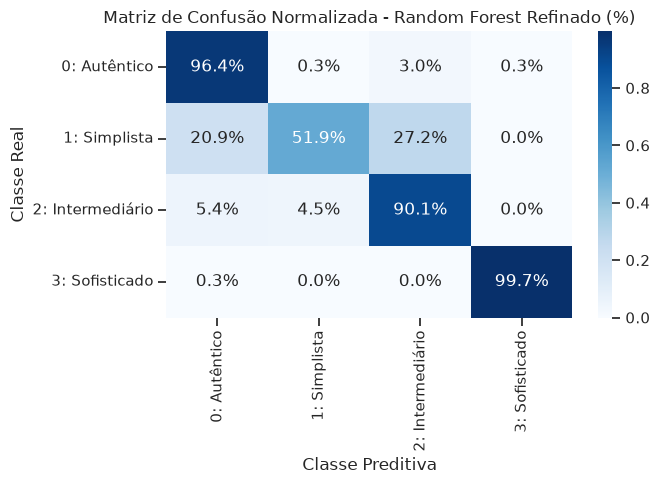

================ RELATÓRIO RANDOM FOREST REFINADO ================
              precision    recall  f1-score   support

           0       0.99      0.96      0.98     67652
           1       0.57      0.52      0.54      1301
           2       0.73      0.90      0.80      7047
           3       0.93      1.00      0.96      3000

    accuracy                           0.95     79000
   macro avg       0.81      0.85      0.82     79000
weighted avg       0.96      0.95      0.95     79000



In [32]:
# Feature Engineering: Média Móvel Contínua (Rolling Window de 5 instantes)
# Suaviza o ruído instantâneo mantendo a tendência física do sinal
X_rolling = X_completo.rolling(window=5, min_periods=1).mean()
X_rolling.columns = [f"{col}_roll5" for col in X_rolling.columns]

# Concatena atributos originais + médias móveis
X_rf_refinado = pd.concat([X_completo, X_rolling], axis=1)

# 2. Re-aplicar a divisão por janelas contínuas (Janelas Pares = Treino | Ímpares = Teste)
X_train_rf = X_rf_refinado[data_ordenado['janela_id'].isin(janelas_treino)]
X_test_rf = X_rf_refinado[data_ordenado['janela_id'].isin(janelas_teste)]

# Pesos Customizados (Penaliza severamente os erros na Classe 1)
# Formato: {Classe: Peso}
pesos_customizados = {
    0: 1.0,   # Autêntico (abundante)
    1: 8.0,   # Simplista (peso alto para forçar o aprendizado)
    2: 2.0,   # Intermediário
    3: 3.0    # Sofisticado
}

# Treinamento da Random Forest Refinada
rf_refinado = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    class_weight=pesos_customizados,
    max_depth=15, # Evita memorização excessiva do ruído
    n_jobs=-1
)

rf_refinado.fit(X_train_rf, y_train)

# Predição
y_pred_rf_ref = rf_refinado.predict(X_test_rf)

# Exibição da Matriz Normalizada (%)
cm_rf_ref = confusion_matrix(y_test, y_pred_rf_ref, normalize='true')

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_rf_ref, 
    annot=True, 
    fmt='.1%', 
    cmap='Blues',
    xticklabels=['0: Autêntico', '1: Simplista', '2: Intermediário', '3: Sofisticado'],
    yticklabels=['0: Autêntico', '1: Simplista', '2: Intermediário', '3: Sofisticado']
)
plt.title('Matriz de Confusão Normalizada - Random Forest Refinado (%)')
plt.ylabel('Classe Real')
plt.xlabel('Classe Preditiva')
plt.tight_layout()
plt.show()

print("================ RELATÓRIO RANDOM FOREST REFINADO ================")
print(classification_report(y_test, y_pred_rf_ref, zero_division=0))

### **4.3 Pós-processamento**

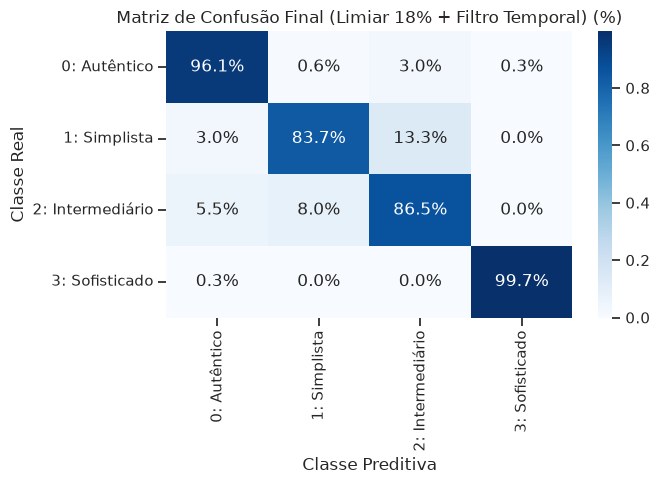

================ RELATÓRIO COMPLETO PÓS-PROCESSADO ================
              precision    recall  f1-score   support

           0       0.99      0.96      0.98     67652
           1       0.53      0.84      0.65      1301
           2       0.74      0.87      0.80      7047
           3       0.93      1.00      0.96      3000

    accuracy                           0.95     79000
   macro avg       0.80      0.92      0.85     79000
weighted avg       0.96      0.95      0.95     79000



In [ ]:
# Pós-processamento: Limiar de decisão + filtro temporal
from scipy.stats import mode


# Extrai as probabilidades continuas do Random Forest
y_probs = rf_refinado.predict_proba(X_test_rf)

# Aplica Limiar Customizado (Força Classe 1 se Probabilidade > 18%)
y_pred_limiar = y_probs.argmax(axis=1)
limiar_c1 = 0.18
y_pred_limiar[y_probs[:, 1] > limiar_c1] = 1

# Função do Filtro Temporal (Majority Voting)
def aplicar_filtro_temporal(predicoes, tamanho_janela=5):
    pred_series = pd.Series(predicoes)
    pred_suavizada = pred_series.rolling(window=tamanho_janela, min_periods=1, center=True).apply(
        lambda x: mode(x, keepdims=False)[0]
    )
    return pred_suavizada.astype(int)

# Aplica o Filtro Temporal em cima das predições com limiar ajustado
y_pred_final = aplicar_filtro_temporal(y_pred_limiar, tamanho_janela=5)

# Exibição da Matriz de Confusão Final
cm_final = confusion_matrix(y_test, y_pred_final, normalize='true')

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_final, 
    annot=True, 
    fmt='.1%', 
    cmap='Blues',
    xticklabels=['0: Autêntico', '1: Simplista', '2: Intermediário', '3: Sofisticado'],
    yticklabels=['0: Autêntico', '1: Simplista', '2: Intermediário', '3: Sofisticado']
)
plt.title('Matriz de Confusão Final (Limiar 18% + Filtro Temporal) (%)')
plt.ylabel('Classe Real')
plt.xlabel('Classe Preditiva')
plt.tight_layout()
plt.show()

print("================ RELATÓRIO COMPLETO PÓS-PROCESSADO ================")
print(classification_report(y_test, y_pred_final, zero_division=0))

---
## **5. Comparação entre os modelos**


**Comparativo do desempenho entre os modelos**

| Modelo | Acurácia | F1-Score (Classe 1) | Recall (Classe 1) | Precision (Classe 1) | Macro F1-Score |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Random Forest (Refinado)** | 0.95 | 0.54 | 0.52 | 0.57 | 0.82 |
| **XGBoost Otimizado** | **0.96** | 0.58 | 0.48 | **0.74** | 0.82 |
| **RF + Pós-Processamento** | 0.95 | **0.65** | **0.84** | 0.53 | **0.85** |

**F1-Score Detalhado por Classe**

| Modelo | Classe 0 | Classe 1 | Classe 2 | Classe 3 |
| :--- | :---: | :---: | :---: | :---: |
| **Random Forest (Refinado)** | 0.98 | 0.54 | 0.80 | **0.96** |
| **XGBoost Otimizado** | 0.98 | 0.58 | **0.84** | 0.90 |
| **RF + Pós-Processamento** | 0.98 | **0.65** | 0.80 | **0.96** |

- **XGBoost Otimizado:** Apresentou a maior precisão na Classe 1 (0.74) e maior acurácia global (0.96), porém falhou em capturar mais da metade das anomalias da Classe 1 (Recall de 0.48).
- **Random Forest + Pós-Processamento:** Foi o modelo de melhor desempenho prático, elevando a taxa de detecção (Recall) da Classe 1 de **0.52 para 0.84**, o que aumentou o **Macro F1-Score para 0.85**.

---

## **6. Conclusão**
- **Resumo do desempenho:** o modelo **Random Forest combinado com Pós-Processamento** destacou-se como a melhor solução para o problema, atingindo um **Recall de 0,84 e F1-Score de 0,65** na classe de ataque crítica (spoofing simplista), o que elevou o **Macro F1-Score para 0,85**. Embora o XGBoost otimizado tenha obtido maior precisão pontual (0,74), ele deixou de detectar _mais da metade dos ataques_ (Recall de 0,48).
- **Importância das features:** as features principais para identificação das interferências foram **as variações abruptas no CN0 (relação sinal-ruído)**, **oscilações atípicas no desvio Doppler** e **discrepâncias relativas** de **Pseudorange** entre os 8 canais de recepção.
- **Limitações e trabalhos futuros:** o aumento substancial no recall da Classe 1 trouxe como _trade-off_ uma redução moderada na precisão (0,53), gerando mais falsos alarmes. Para trabalhos futuros, seria interessante a exploração de modelos temporais, como LSTMs, para capturar a dinâmica do sinal ao longo do tempo ou testar técnicas avançadas de agregação de features entre os canais.

# Estudos em Machine Learning & Data Science

Este repositório reúne meus notebooks pessoais de anotações, códigos conceituais e projetos práticos criados durante meus estudos de Ciência de Dados e Aprendizado de Máquina. O objetivo é consolidar a base matemática e computacional para pesquisas de **Iniciação Científica (IC)** no **ICMC/USP**.

---

## Estrutura do Repositório

O projeto está organizado de forma modular, cobrindo desde a fundamentação em bibliotecas essenciais até estudos de caso com dados complexos de sensores:

* **`notas-pandas.ipynb`**: Manipulação de dados tabulares, estruturas fundamentais (`Series` e `DataFrame`), técnicas de filtragem, ordenação, gerenciamento de memória (View vs. Copy), tratamento de valores nulos, agrupamentos com `groupby` e junções com `merge`.
* **`notas-matplotlib.ipynb`**: Fundamentos de visualização de dados, mapeamento da hierarquia `Figures` e `Axes`, gráficos estatísticos (linhas, dispersão, barras, histogramas) e matrizes de correlação com mapas de calor.
* **`notas-analise-e-pre-processamento.ipynb`**: Limpeza de dados reais utilizando o dataset do Titanic. Inclui engenharia de recursos, tratamento avançado de dados ausentes com imputação por mediana filtrada e detecção de *outliers* através de boxplots.
* **`notas-scikit-learn.ipynb`**: Introdução prática aos paradigmas de Machine Learning (Supervisionado e Não Supervisionado), cobrindo regressão linear, classificação linear, mapeamento espacial com kernels e algoritmos de agrupamento (*Clustering*) como o DBSCAN.
* **`detecção-spoofing-uas.ipynb`**: Aplicação avançada de Machine Learning para segurança em sistemas aéreos não tripulados (UAS/Drones) via processamento de sinais GNSS.

---

## Projetos & Estudos de Caso

### 1. Detecção de Spoofing GNSS em UAS (Projeto de Aplicação)

Estudo focado na identificação de ataques de falsificação de sinal GNSS (*spoofing*) em drones a partir de dados temporais multicanais de receptores a bordo.

* **Engenharia de Features de Domínio Físico:** Construção da métrica $\vert{}Doppler - TCD\vert{}$ para mensurar incoerências físicas entre a fase da portadora e o deslocamento Doppler nos 8 canais de satélite visíveis.
* **Validação Cruzada Consciente de Séries Temporais:** Substituição do *shuffle* aleatório por validação baseada em blocos de janelas contínuas para evitar o vazamento de dados (*data leakage*) decorrente da autocorrelação temporal.
* **Pós-Processamento Temporal:** Aplicação de redução do limiar de decisão de probabilidade (ajustado para 18%) combinada a um filtro de votação majoritária (*majority voting*), elevando a taxa de detecção (*Recall*) do ataque de **52% para 84%**.

---

### 2. Pipeline Clássico de Classificação (Dataset Iris)

Demonstração de um pipeline padronizado e reprodutível de Aprendizado de Máquina para tarefas de classificação supervisionada:

1. **Análise Exploratória (EDA):** Mapeamento de distribuições e validação visual da separabilidade das classes com Seaborn e Matplotlib.
2. **Seleção de Algoritmo:** Validação Cruzada (*5-Fold Cross-Validation*) comparando **SVC**, **Random Forest** e **KNN**.
3. **Diagnóstico Final:** Divisão determinística (`random_state=42`), avaliação via relatório de classificação e análise de matriz de confusão.

#### Resultados Visuais (Dataset Iris)

##### Distribuição e Correlação das Espécies (Pairplot)
![Pairplot do Dataset Iris](Imagens/pairplot_iris.png)

##### Avaliação do Modelo Campeão (Matriz de Confusão - KNN)
![Matriz de Confusão do KNN](Imagens/matriz_confusao.png)

---

## Tecnologias Utilizadas

* **Linguagem:** Python 3
* **Análise e Manipulação:** Pandas, NumPy
* **Visualização:** Matplotlib, Seaborn
* **Machine Learning:** Scikit-Learn

---

## Autor

Desenvolvido por **Luís Henrique Varela Medeiros Bezerra** 
* Aluno de Bacharelado em Ciência de Computação (BCC) — **ICMC/USP**
* [GitHub Profile](https://github.com/luishvarela)